In [16]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from app.data_providers import provide_dataframe, DataFrameRequest
from processing.fixes import fix_score_column, fix_score_columns_for_all_games
import pandas as pd
import numpy as np
import sys

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
request = DataFrameRequest(
    add_computed = True,
    filter_pre_encoding_columns = False,
    encode_for_model = False,
    filter_top_players=True,
    filter_clean= False
)
# pipeline execution

df = provide_dataframe(request)


Repo card metadata block was not found. Setting CardData to empty.


In [3]:
df.head()

,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,yLegacy,...,pointsAway,scoreHomeBeforeShot,scoreAwayBeforeShot,scoreMargin,scoreMarginBeforeShot,OPPONENT_INTERFERED,ANGLE,ANGLE_SECTOR,ABS_ANGLE,MAIN_ACTION_TYPE
966362,34,PT08M08.00S,1,1610612742,DAL,1717,Nowitzki,D. Nowitzki,0,0,...,0,0.0,0.0,0,0.0,False,0.000000,0,0.000000,Layup
966369,49,PT06M31.00S,1,1610612742,DAL,1717,Nowitzki,D. Nowitzki,-103,226,...,0,0.0,0.0,0,0.0,False,-24.501231,0,24.501231,Jump
966420,174,PT07M17.00S,2,1610612742,DAL,1717,Nowitzki,D. Nowitzki,-231,2,...,0,0.0,0.0,3,0.0,False,-89.503945,1,89.503945,Jump
966425,186,PT05M37.00S,2,1610612742,DAL,1717,Nowitzki,D. Nowitzki,159,104,...,0,3.0,0.0,5,3.0,False,56.811780,1,56.811780,Jump
966432,204,PT04M06.00S,2,1610612742,DAL,1717,Nowitzki,D. Nowitzki,0,15,...,0,5.0,0.0,6,5.0,False,0.000000,0,0.000000,Other


In [4]:
df.columns

Index(['actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId',
       'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance',
       'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal',
       'location', 'description', 'actionType', 'subType', 'videoAvailable',
       'actionId', 'gameId', 'GRID_TYPE', 'GAME_ID_x', 'GAME_EVENT_ID',
       'PLAYER_ID', 'PLAYER_NAME', 'TEAM_ID', 'TEAM_NAME', 'PERIOD_x',
       'MINUTES_REMAINING', 'SECONDS_REMAINING', 'EVENT_TYPE', 'ACTION_TYPE',
       'SHOT_TYPE', 'SHOT_ZONE_BASIC', 'SHOT_ZONE_AREA', 'SHOT_ZONE_RANGE',
       'SHOT_DISTANCE', 'LOC_X', 'LOC_Y', 'SHOT_ATTEMPTED_FLAG',
       'SHOT_MADE_FLAG', 'GAME_DATE', 'HTM', 'VTM', 'GAME_ID_y', 'EVENTNUM',
       'EVENTMSGTYPE', 'EVENTMSGACTIONTYPE', 'PERIOD_y', 'WCTIMESTRING',
       'PCTIMESTRING', 'HOMEDESCRIPTION', 'NEUTRALDESCRIPTION',
       'VISITORDESCRIPTION', 'SCORE', 'SCOREMARGIN', 'PERSON1TYPE',
       'PLAYER1_ID', 'PLAYER1_NAME', 'PLAYER1_TEA

<Axes: >

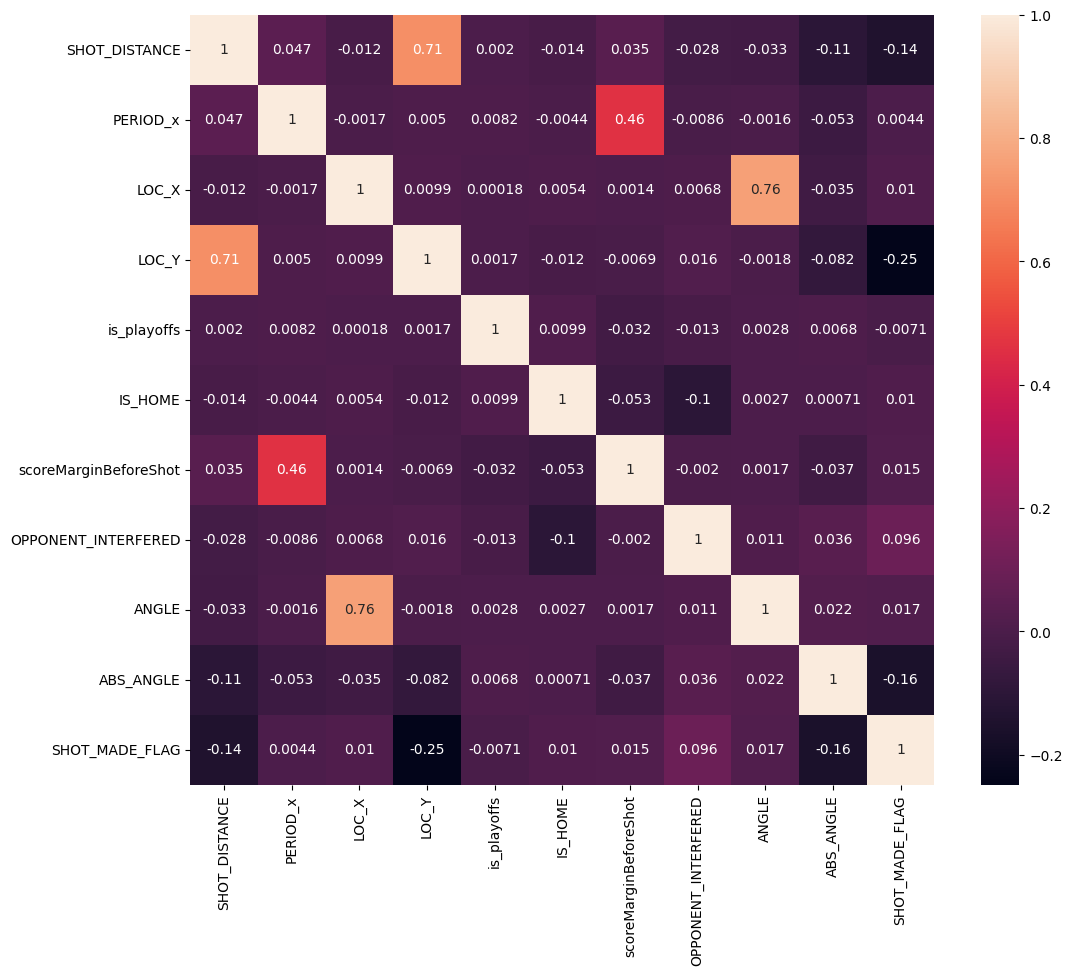

In [9]:
cols = ['SHOT_DISTANCE', 'PERIOD_x', 'LOC_X', 'LOC_Y', 'is_playoffs', 'IS_HOME', 'scoreMarginBeforeShot', 'OPPONENT_INTERFERED', 'ANGLE', 'ABS_ANGLE', 'SHOT_MADE_FLAG']

plt.figure(figsize=(12,10))
sns.heatmap(df[cols].corr(), annot=True)

<Axes: xlabel='SHOT_MADE_FLAG', ylabel='percent'>

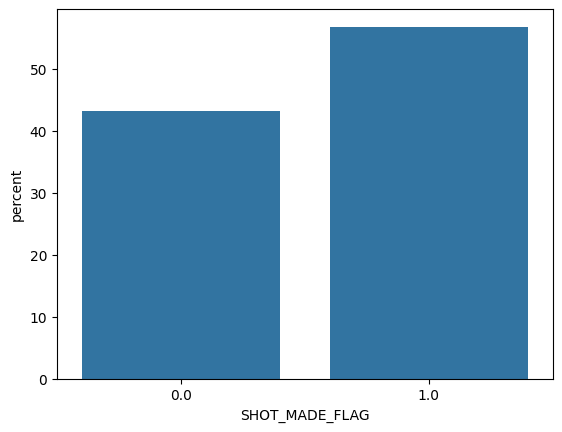

In [11]:
sns.countplot(df, x='SHOT_MADE_FLAG', stat='percent')

# Test for Location clustering/classification

In [36]:
from scipy.stats import chi2_contingency
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.model_selection import train_test_split

In [37]:
def chi2_test_with_cramers_v(df, feature, target="SHOT_MADE_FLAG"):
    
    contingency = pd.crosstab(df[feature], df[target])
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    # cramersV
    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))
    
    print(f"Feature: {feature}")
    print(f"Chi2: {chi2:.2f}, p-value: {p:.5f}, dof: {dof}")
    print(f"Cramér's V: {cramers_v:.3f}")
    print("-" * 40)
    
    return {
        "feature": feature,
        "chi2": chi2,
        "p_value": p,
        "cramers_v": cramers_v
    }

In [38]:
features = [
    "SHOT_ZONE_BASIC",
    "SHOT_ZONE_AREA",
    "SHOT_ZONE_RANGE"
]

results = []
for f in features:
    res = chi2_test_with_cramers_v(df, f)
    results.append(res)

results_df = pd.DataFrame(results)
print(results_df)

Feature: SHOT_ZONE_BASIC
Chi2: 28059.63, p-value: 0.00000, dof: 6
Cramér's V: 0.228
----------------------------------------
Feature: SHOT_ZONE_AREA
Chi2: 30996.08, p-value: 0.00000, dof: 5
Cramér's V: 0.240
----------------------------------------
Feature: SHOT_ZONE_RANGE
Chi2: 33205.98, p-value: 0.00000, dof: 4
Cramér's V: 0.248
----------------------------------------
           feature          chi2  p_value  cramers_v
0  SHOT_ZONE_BASIC  28059.633186      0.0   0.228395
1   SHOT_ZONE_AREA  30996.077342      0.0   0.240048
2  SHOT_ZONE_RANGE  33205.983661      0.0   0.248458


In [39]:
def plot_shot_percentages(df, feature, target="SHOT_MADE_FLAG"):
    rates = df.groupby(feature)[target].mean().sort_values(ascending=False)
    counts = df[feature].value_counts()
    
    result = pd.DataFrame({
        "hit_rate": rates,
        "count": counts
    })
    
    print(f"\n{feature} - hit_rate:")
    print(result)
    
    return result

for f in features:
    plot_shot_percentages(df, f)


SHOT_ZONE_BASIC - hit_rate:
                       hit_rate   count
SHOT_ZONE_BASIC                        
Above the Break 3      0.355900   74167
Backcourt              0.027496     691
In The Paint (Non-RA)  0.443851   68514
Left Corner 3          0.388811    5684
Mid-Range              0.628516  265858
Restricted Area        0.658682  117644
Right Corner 3         0.391889    5351

SHOT_ZONE_AREA - hit_rate:
                       hit_rate   count
SHOT_ZONE_AREA                         
Back Court(BC)         0.029448     815
Center(C)              0.649739  363714
Left Side Center(LC)   0.379394   44036
Left Side(L)           0.414845   45417
Right Side Center(RC)  0.387510   44275
Right Side(R)          0.420408   39652

SHOT_ZONE_RANGE - hit_rate:
                 hit_rate   count
SHOT_ZONE_RANGE                  
16-24 ft.        0.420492   72741
24+ ft.          0.360822   85078
8-16 ft.         0.673771  221918
Back Court Shot  0.029448     815
Less Than 8 ft.  0.603005  157

In [40]:
def logistic_regression_with_feature(df, feature, target="SHOT_MADE_FLAG"):
    X = df[[feature]]
    y = df[target]
    
    # One-Hot Encoding
    encoder = OneHotEncoder(drop='first', sparse_output=False)
    X_encoded = encoder.fit_transform(X)
    
    # Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded, y, test_size=0.2, random_state=42
    )
    
    # Modell
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    auc = roc_auc_score(y_test, y_pred_proba)
    ll = log_loss(y_test, y_pred_proba)
    
    print(f"\nFeature: {feature}")
    print(f"ROC-AUC: {auc:.4f}")
    print(f"Log Loss: {ll:.4f}")
    
    # print coefficients
    feature_names = encoder.get_feature_names_out([feature])
    coefs = pd.Series(model.coef_[0], index=feature_names)
    
    print("\nCoefficients:")
    print(coefs.sort_values(ascending=False))
    
    return model, encoder

for f in features:
    logistic_regression_with_feature(df, f)


Feature: SHOT_ZONE_BASIC
ROC-AUC: 0.6123
Log Loss: 0.6568

Coefficients:
SHOT_ZONE_BASIC_Restricted Area          1.251777
SHOT_ZONE_BASIC_Mid-Range                1.120466
SHOT_ZONE_BASIC_In The Paint (Non-RA)    0.375010
SHOT_ZONE_BASIC_Right Corner 3           0.168500
SHOT_ZONE_BASIC_Left Corner 3            0.154891
SHOT_ZONE_BASIC_Backcourt               -2.903140
dtype: float64

Feature: SHOT_ZONE_AREA
ROC-AUC: 0.6146
Log Loss: 0.6544

Coefficients:
SHOT_ZONE_AREA_Center(C)                3.457857
SHOT_ZONE_AREA_Right Side(R)            2.518926
SHOT_ZONE_AREA_Left Side(L)             2.490123
SHOT_ZONE_AREA_Right Side Center(RC)    2.385572
SHOT_ZONE_AREA_Left Side Center(LC)     2.351702
dtype: float64

Feature: SHOT_ZONE_RANGE
ROC-AUC: 0.6331
Log Loss: 0.6508

Coefficients:
SHOT_ZONE_RANGE_8-16 ft.           1.031311
SHOT_ZONE_RANGE_Less Than 8 ft.    0.728972
SHOT_ZONE_RANGE_24+ ft.           -0.259474
SHOT_ZONE_RANGE_Back Court Shot   -2.832995
dtype: float64


In [41]:
def compare_models(df, numeric_features, categorical_features, target="SHOT_MADE_FLAG"):
    
    y = df[target]
    
    # numerical features
    X_num = df[numeric_features].values
    
    # catecorical features
    encoder = OneHotEncoder(drop='first', sparse_output=False)
    X_cat = encoder.fit_transform(df[categorical_features])
    
    X_A = X_num
    X_B = np.hstack([X_num, X_cat])
    X_C = X_cat
    
    X_train_A, X_test_A, y_train, y_test = train_test_split(
        X_A, y, test_size=0.2, random_state=42
    )
    
    X_train_B, X_test_B, _, _ = train_test_split(
        X_B, y, test_size=0.2, random_state=42
    )

    X_train_C, X_test_C, _, _ = train_test_split(
        X_C, y, test_size=0.2, random_state=42
    )
    
    model_A = LogisticRegression(max_iter=1000)
    model_B = LogisticRegression(max_iter=1000)
    model_C = LogisticRegression(max_iter=1000)
    
    model_A.fit(X_train_A, y_train)
    model_B.fit(X_train_B, y_train)
    model_C.fit(X_train_C, y_train)
    
    pred_A = model_A.predict_proba(X_test_A)[:, 1]
    pred_B = model_B.predict_proba(X_test_B)[:, 1]
    pred_C = model_C.predict_proba(X_test_C)[:, 1]
    
    print("\nModel A (only numeric):")
    print("AUC:", roc_auc_score(y_test, pred_A))
    
    print("\nModel B (+ zones):")
    print("AUC:", roc_auc_score(y_test, pred_B))

    print("\nModel C (only zones):")
    print("AUC:", roc_auc_score(y_test, pred_C))

In [42]:
numeric_features = ["LOC_X", "LOC_Y"]

categorical_features = ["SHOT_ZONE_RANGE"]  # nur das beste

compare_models(df, numeric_features, categorical_features)


Model A (nur numerisch):
AUC: 0.6449935034574199

Model B (+ Zonen):
AUC: 0.6701165023440754

Model C (only zones):
AUC: 0.6331134055576081


In [43]:
df["angle_sin"] = np.sin(df["ANGLE"])
df["angle_cos"] = np.cos(df["ANGLE"])

In [44]:
numeric_features = ["angle_sin", "angle_cos"]

categorical_features = ["SHOT_ZONE_RANGE"]  # nur das beste

compare_models(df, numeric_features, categorical_features)


Model A (nur numerisch):
AUC: 0.6384307297585778

Model B (+ Zonen):
AUC: 0.6733441002370485

Model C (only zones):
AUC: 0.6331134055576081


In [45]:
numeric_features = ["angle_sin", "angle_cos", "SHOT_DISTANCE"]

categorical_features = ["SHOT_ZONE_RANGE"]  # nur das beste

compare_models(df, numeric_features, categorical_features)


Model A (nur numerisch):
AUC: 0.6357601268553992

Model B (+ Zonen):
AUC: 0.6711262135671123

Model C (only zones):
AUC: 0.6331134055576081
